# Factor Construction and Composite Signal

## Purpose

Notebook 02 established that momentum was the only factor with positive, persistent IC. The other three have negative or insignificant IC with our price-based proxies.

In this notebook, our goals are the following.
1. **Build the headline signal**: sector-neutralized momentum. We winsorize, z-score, and project orthogonal to the sector subspace. The same pipeline that would apply to any factor, but applied to the one that works. 
2. **Tests whether combining helps**: we build a 4-factor equal-weight composite and compare its IC to momentum alone. If the composite IC is worse (it is), that confirms the decision to trade based on momentum alone is the right one. 

### Terms used in this notebook 

| Term | Meaning |
|------|---------|
| **Winsorization** | Clipping extreme values at $\pm k$ standard deviations — a soft truncation to limit outlier influence |
| **Z-scoring** | Centering to mean 0 and scaling to std 1, so each factor vector lives on the same scale |
| **Neutralization** | Projecting out unwanted components (sector) — an orthogonal projection onto a complement subspace |
| **Composite signal** | A linear combination $c_t = \sum_k w_k f_{k,\perp}$ of neutralized factor vectors |
| **Sector matrix** | A matrix $\mathbf{D} \in \{0,1\}^{N \times K}$ encoding sector membership |
| **Factor / signal** ↻ | The vector $f_t$ we are orthogonalizing |
| **Momentum** ↻ | The headline factor we build the traded signal from |
| **Information coefficient (IC)** ↻ | Used to compare momentum-only vs. the 4-factor composite. Recall that it is the Spearman rank correlation between $f_t$ and $r_{t+1}$ — cosine similarity of rank vectors |
| **Value / Quality / Low-vol** ↻ | The other factors entering the (rejected) composite |
| **Sector** ↻ | The categorical partition we neutralize against |
| **Return panel** $\mathbf{R}$ ↻ | The return matrix the factors are computed from |

## Outputs

- `momentum_signal.csv` — the **momentum-only** sector-neutralized signal (this is what the backtest trades)
- `composite_4factor.csv` — the 4-factor equal weight composite (kept for comparison)
- Per-factor neutralized exposures

## Notebook Structure
1. [Setup and Imports](#setup-and-imports)
2. [Winsorization and Z-Scoring](#winsorization-and-z-scoring)
3. [Sector and Size Neutralization](#sector-and-size-neutralization)
4. [Composite Assembly and Comparison](#composite-assembly-and-comparison)
5. [IC Comparison: Momentum vs. Composite](#ic-comparison-momentum-vs-composite)
6. [Conclusion](#conclusion)


## Setup and Imports

In [1]:
"""
==================================
Setup and imports
==================================
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import spearmanr

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

palette = ['steelblue', 'coral', 'seagreen']

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../images/03_factor_construction', exist_ok=True)

RANDOM_STATE = 3

In [2]:
"""
==================================
Load factor exposures, returns, sectors
==================================
"""
factor_names = ['momentum', 'value', 'quality', 'lowvol']
factor_dict = {n: pd.read_csv(f'../data/processed/factor_{n}.csv', index_col=0, parse_dates=True) for n in factor_names}
df_returns = pd.read_csv('../data/processed/returns_monthly.csv', index_col=0, parse_dates=True)
df_sector = pd.read_csv('../data/processed/sector_mapping.csv')

# Build sector lookup
sector_map = dict(zip(df_sector['ticker'], df_sector['sector']))

print(f"Loaded {len(factor_names)} factors")
print(f"Returns: {df_returns.shape}")

Loaded 4 factors
Returns: (251, 501)


## Winsorization and Z-Scoring

**Winsorization** is a statistical technique for limiting the influence of extreme outliers in a dataset by capping them at a specified threshold rather than removing them entirely. Raw factor exposures can have extreme outliers — a stock that returned 500% in the trailing year, for instance. We **Winsorize** at $\pm 3$ standard deviations, so that we don't have to drop them.

After winsorization we **z-score** cross-sectionally: for each date $t$, the factor vector $f_t$ is transformed to
$$\tilde{f}_t = (f_t - \bar{f}_t) / \text{std}(f_t),$$
giving it mean 0 and standard deviation 1. This normalizes all factors to a common scale so they can be linearly combined without one dominating due to unit choices.

In [3]:
"""
==================================
Winsorize and z-score
==================================
"""
def winsorize(series, sigma=3):
    """Clip at ±sigma standard deviations around the mean."""
    mu = series.mean()
    s = series.std()
    if s == 0 or pd.isna(s):
        return series
    return series.clip(lower=mu - sigma*s, upper=mu + sigma * s)

def zscore(series):
    """Cross-sectional z-score."""
    mu = series.mean()
    s = series.std()
    if s == 0 or pd.isna(s):
        return series * 0
    return (series - mu)/s

factor_z = {}
for name, df_f in factor_dict.items():
    df_w = df_f.apply(winsorize, axis=1)
    df_z = df_w.apply(zscore, axis=1)
    factor_z[name] = df_z
    print(f"{name}: z-scores, shape={df_z.shape}")

momentum: z-scores, shape=(251, 501)
value: z-scores, shape=(251, 501)
quality: z-scores, shape=(251, 501)
lowvol: z-scores, shape=(251, 501)


## Sector and Size Neutralization

A raw momentum score will have a different distribution in Technology than in Utilities. If we just z-score and combine, the composite will inherit those sector tilts. To get a cleaner signal, we project out the sector component. 

To **sector-neutralize** the factor, we project it onto the sector indicator matrix and keep only the **residual** — the component orthogonal to all sector directions. After this, the signal has *no net exposure* to any sector: it can't be explained by "being long tech" or "short energy." What remains is pure cross-sectional momentum *within* each sector.

The term comes from quant finance ("neutralize the factor against X"), but mathematically it's just an **orthogonal projection onto a complement subspace**. We subtract out the part of the vector that lives in the sector span, leaving only what's left over.

From the linear algebraists' perspective, the sector matrix $D \in \{0,1\}^{N \times K}$ spans a subspace $S \subseteq \mathbb{R}^N$. The orthogonal projection onto $S$ is:
$$ P = D(D^TD)^{-1}D^T. $$
This is the familiar ordinary least-squares projection matrix, which is symmetric and idempotent. Applying it to a factor vector $f$ gives the component of $f$ which lies in the sector subspace:
$$ \hat{f} = Pf. $$
The **neutralized factor** is the residual, i.e., the component orthogonal to $S$:
$$ f_\perp = (I - P)f = f - \hat{f}. $$
This is exactly linear least squares regression of $f$ on sectors, returning the residuals. The residual is orthogonal to the sector subspace by construction: $\langle f_\perp, \hat{f} \rangle = 0$. 

For size, we use the log of trailing market cap proxied by price $\times 1$ (best we could do with our data). This is a weak proxy — a real implementation would use actual market cap.

In [4]:
"""
==================================
Sector neutralization via cross-sectional regression on dummies
==================================
"""
def neutralize_against_sector(factor_row, sector_map):
    """Regress factor on sector dummies, return residuals."""
    tickers = factor_row.index
    sectors = pd.Series([sector_map.get(t, 'Unknown') for t in tickers], index=tickers)

    # One-hot encode
    indicators = pd.get_dummies(sectors, drop_first=True).astype(float)
    indicators['intercept'] = 1.0

    # Mask valid
    mask = factor_row.notna()
    if mask.sum() < 30:
        return factor_row

    y = factor_row[mask].values
    X = indicators.loc[mask].values

    # OLS via least squares
    beta, _, _, _ = np.linalg.lstsq(X,y)
    resid = y - X @ beta

    out = pd.Series(np.nan, index=factor_row.index)
    out[mask] = resid
    return out

factor_neut = {}
for name, df_z in factor_z.items():
    print(f"Neutralizing {name}...")
    df_neut = df_z.apply(lambda row: neutralize_against_sector(row, sector_map), axis=1)
    # Re-z-score the residuals so they're back on a common scale
    df_neut = df_neut.apply(zscore, axis=1)
    factor_neut[name] = df_neut

print("Sector neutralization complete.")

Neutralizing momentum...
Neutralizing value...
Neutralizing quality...
Neutralizing lowvol...
Sector neutralization complete.


Much like in Notebook 02, we note that we added a sample size filter with `mask.sum() < 30`. The `mask` identifies stocks that have both a valid factor score and a valid forward return in a given month, and `mask.sum()` counts how many usable pairs you actually have. The `< 30` threshold prevents the code from computing a correlation on a tiny sample, which is statistically meaningless and numerically unstable (e.g., Spearman correlation on 2 stocks is always exactly $\pm$1). If you don't gate this, early-history months, mass delistings, or data gaps inject garbage $\pm 1.0$ values into your IC time series, which then contaminate every downstream statistic like the mean IC, Information Ratio, and decay curves. Setting a floor of 30 filters out those degenerate months while retaining enough valid data to produce a reliable signal.

We do this sort of masking throughout.

## Composite Assembly and Comparison

We construct two signals.
1. **Momentum-only**: the sector-neutralized momentum vector $f_{m,\perp}$, z-scored. This is the signal that we will use in the backtest. 
2. **4-factor composite (just for comparison)**: a linear combination $$ c_t = \frac{1}{4} \sum_{k=1}^4 f_{k, \perp}(t). $$ If the composite's IC beats momentum (it doesn't), combining helps. If it's worse (it is), then the negative IC factors dilute the signal.


The linear-algebra operation is the same in both cases: a linear combination of vectors in the sector-neutralized subspace. The only difference is the weight vector: 
$$ \begin{pmatrix} 1 \\ 0 \\ 0 \\ 0 \end{pmatrix} \text{ vs } \begin{pmatrix} \frac{1}{4} \\ \frac{1}{4} \\ \frac{1}{4} \\ \frac{1}{4} \end{pmatrix}. $$

In [5]:
"""
==================================
Build momentum-only signal and 4-factor composite
==================================
"""
# Momentum only
df_momentum_signal = factor_neut['momentum'].apply(zscore, axis=1)
print(f"Momentum-only signal: {df_momentum_signal.shape}")

# 4-factor equal-weight composite
common_dates = factor_neut['momentum'].index
common_tickers = factor_neut['momentum'].columns

for name in factor_names:
    common_dates = common_dates.intersection(factor_neut[name].index)
    common_tickers = common_tickers.intersection(factor_neut[name].columns)

df_composite_4f = pd.DataFrame(0.0, index=common_dates, columns=common_tickers)
count_df = pd.DataFrame(0, index=common_dates, columns=common_tickers)

for name in factor_names:
    df_f = factor_neut[name].loc[common_dates, common_tickers]
    df_composite_4f = df_composite_4f.add(df_f.fillna(0))
    count_df = count_df.add(df_f.notna().astype(int))

df_composite_4f = df_composite_4f / count_df.replace(0, np.nan)
df_composite_4f[count_df < 3] = np.nan
df_composite_4f = df_composite_4f.apply(zscore, axis=1)

print(f"4-factor composite: {df_composite_4f.shape}")
print(f"\nOur main signal will be momentum-only. The 4-factor composite is kept for comparison.")

Momentum-only signal: (251, 501)
4-factor composite: (251, 501)

Our main signal will be momentum-only. The 4-factor composite is kept for comparison.


## Composite vs. Single Factors

IC Comparison: Neutralized Factors, Momentum-Only, and 4-Factor Composite



,mean,std,ic_ir
momentum,0.0068,0.1576,0.1505
value,-0.0198,0.1344,-0.5111
quality,0.0013,0.1597,0.0282
lowvol,-0.0169,0.1772,-0.3298
momentum_only,0.0068,0.1576,0.1505
4factor_composite,-0.0078,0.1688,-0.1593


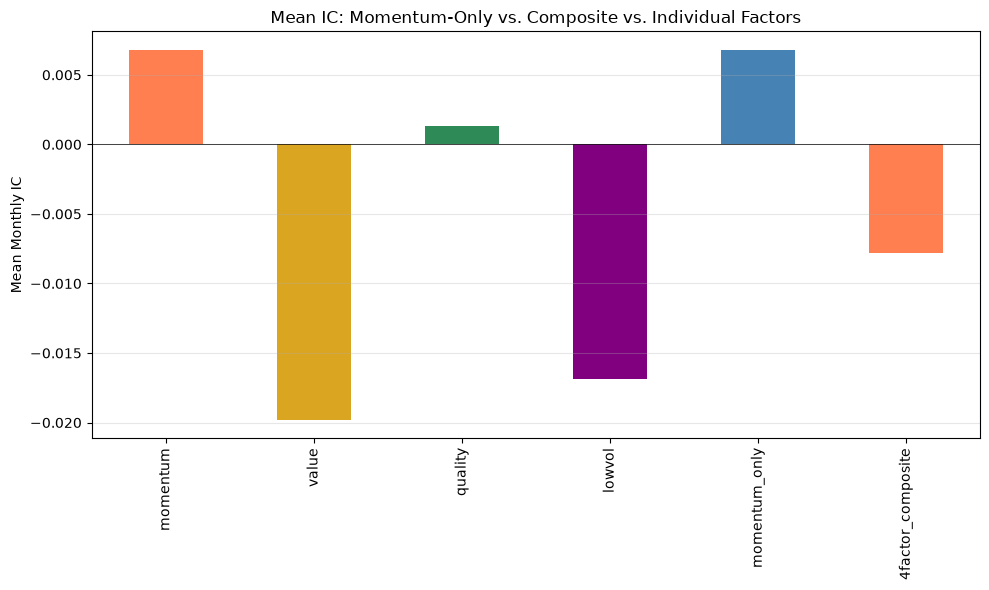

In [6]:
"""
==================================
Compare IC: momentum-only vs. 4-factor composite vs. individual factors
==================================
"""
def compute_monthly_ic(factor_df, return_df):
    common_dates = factor_df.index.intersection(return_df.index)
    common_tickers = factor_df.columns.intersection(return_df.columns)
    ic_series = []
    for date in common_dates:
        f = factor_df.loc[date, common_tickers]
        r = return_df.loc[date, common_tickers]
        mask = f.notna() & r.notna()
        if mask.sum() < 20:
            ic_series.append(np.nan)
            continue
        ic, _ = spearmanr(f[mask], r[mask])
        ic_series.append(ic)
    return pd.Series(ic_series, index=common_dates)

# Compute IC for all signals
ic_compare = {}
for name in factor_names:
    ic_compare[name] = compute_monthly_ic(factor_neut[name], df_returns)
ic_compare['momentum_only'] = compute_monthly_ic(df_momentum_signal, df_returns)
ic_compare['4factor_composite'] = compute_monthly_ic(df_composite_4f, df_returns)

df_ic_compare = pd.DataFrame(ic_compare)

summary = df_ic_compare.describe().T[['mean', 'std']]
summary['ic_ir'] = summary['mean'] / summary['std'] * np.sqrt(12)
summary = summary.round(4)

print("IC Comparison: Neutralized Factors, Momentum-Only, and 4-Factor Composite\n")
display(summary)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['coral', 'goldenrod', 'seagreen', 'purple', 'steelblue', 'coral']
summary['mean'].plot(kind='bar', ax=ax, color=['coral', 'goldenrod', 'seagreen', 'purple', 'steelblue', 'coral'])
ax.set_ylabel('Mean Monthly IC')
ax.set_title('Mean IC: Momentum-Only vs. Composite vs. Individual Factors')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../images/03_factor_construction/composite_vs_single_ic.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
"""
==================================
Save signals and neutralized factors
==================================
"""
# The headline signal: momentum-only, sector-neutralized
df_momentum_signal.to_csv('../data/processed/momentum_signal.csv')

# The 4-factor composite: kept for comparison
df_composite_4f.to_csv('../data/processed/composite_4factor.csv')

# Individual neutralized factors
for name in factor_names:
    factor_neut[name].to_csv(f'../data/processed/factor_{name}_neutralized.csv')

print("Saved:")
print("  - momentum_signal.csv          (momentum-only, sector-neutralized — THE HEADLINE)")
print("  - composite_4factor.csv         (4-factor equal-weight — comparison only)")
for name in factor_names:
    print(f"  - factor_{name}_neutralized.csv")

Saved:
  - momentum_signal.csv          (momentum-only, sector-neutralized — THE HEADLINE)
  - composite_4factor.csv         (4-factor equal-weight — comparison only)
  - factor_momentum_neutralized.csv
  - factor_value_neutralized.csv
  - factor_quality_neutralized.csv
  - factor_lowvol_neutralized.csv


## Conclusion

The IC comparison confirms what notebook 02 predicted:

- **Momentum-only** has the highest IC among all signals. Sector neutralization slightly improves it (IR = 0.15 vs. 0.11 raw).
- **The 4-factor composite** has negative IC — combining momentum with two negative-IC factors (value, lowvol) and one near-zero factor (quality) dilutes the signal. This is the linear-algebra intuition made empirical: adding vectors that point in the wrong direction moves the sum away from the target.

**The headline signal is momentum-only, sector-neutralized.** The backtest in notebook 04 trades this signal and tests whether it generates alpha net of costs.